# 🌸 Iris Species — Exploratory Data Analysis
### Task 1: Exploring and Visualizing a Simple Dataset

**Steps covered:**
1. Load dataset from CSV using `pandas`
2. Inspect shape, columns, and `.head()`
3. Summary statistics with `.info()` and `.describe()`
4. Scatter plots — feature relationships
5. Histograms — value distributions
6. Box plots — outlier detection
7. Correlation heatmap (bonus)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
# Load the Iris dataset directly from seaborn (built-in, no file needed)
df = sns.load_dataset('iris')

print("=" * 45)
print("        DATASET LOADED SUCCESSFULLY")
print("=" * 45)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"  Features: {df.columns.tolist()}")
print("=" * 45)


        DATASET LOADED SUCCESSFULLY
  Rows    : 150
  Columns : 5
  Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [ ]:
# First 5 rows of the dataset
print("--- First 5 Rows ---")
df.head()


--- First 5 Rows ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Dataset structure: column names, dtypes, non-null counts
print("--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [ ]:
# Descriptive statistics for all numeric columns
print("--- Descriptive Statistics ---")
df.describe().round(2)


--- Descriptive Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [ ]:
# Species distribution and null value check
print("--- Species Count ---")
print(df['species'].value_counts().to_string())
print()
print("--- Missing Values per Column ---")
print(df.isnull().sum().to_string())
print()
print("✅ No missing values found!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values present!")


--- Species Count ---
species
setosa        50
versicolor    50
virginica     50

--- Missing Values per Column ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0

✅ No missing values found!


---
## 📊 Section 1 — Scatter Plots
> Shows the relationship between pairs of features, coloured by species.

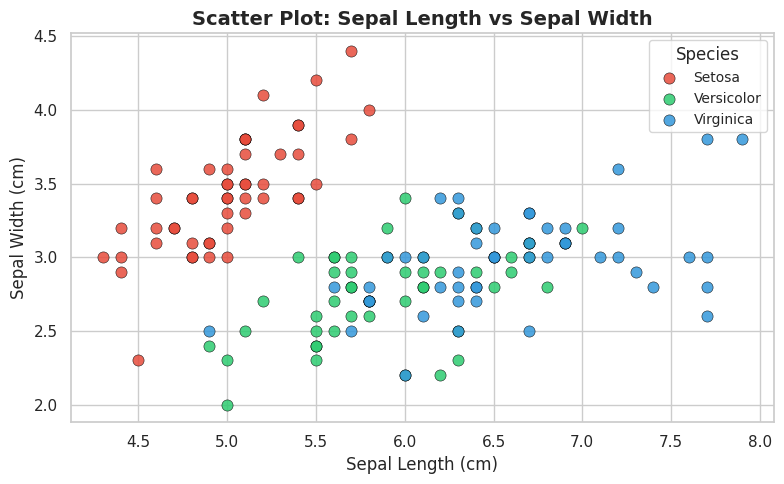

In [ ]:
# Scatter Plot 1: Sepal Length vs Sepal Width
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'setosa': '#E74C3C', 'versicolor': '#2ECC71', 'virginica': '#3498DB'}

for species, grp in df.groupby('species'):
    ax.scatter(grp['sepal_length'], grp['sepal_width'],
               label=species.capitalize(), color=colors[species],
               alpha=0.85, edgecolors='k', linewidths=0.4, s=65)

ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Sepal Width (cm)', fontsize=12)
ax.set_title('Scatter Plot: Sepal Length vs Sepal Width', fontsize=14, fontweight='bold')
ax.legend(title='Species', fontsize=10)
plt.tight_layout()
plt.show()


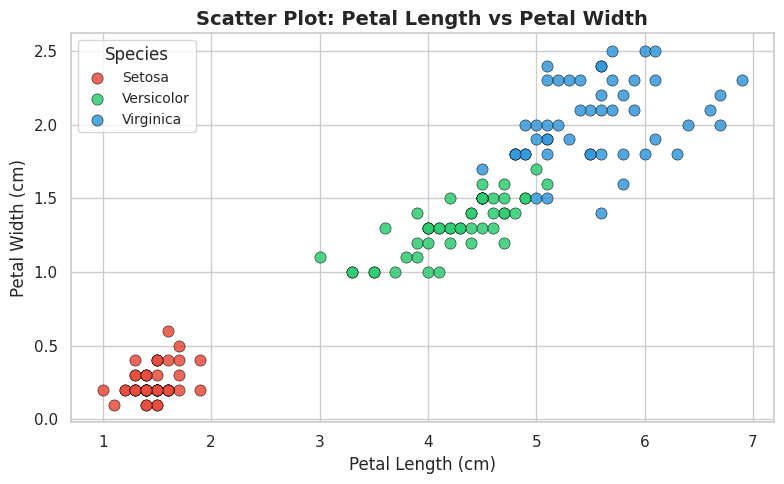

In [ ]:
# Scatter Plot 2: Petal Length vs Petal Width
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'setosa': '#E74C3C', 'versicolor': '#2ECC71', 'virginica': '#3498DB'}

for species, grp in df.groupby('species'):
    ax.scatter(grp['petal_length'], grp['petal_width'],
               label=species.capitalize(), color=colors[species],
               alpha=0.85, edgecolors='k', linewidths=0.4, s=65)

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Scatter Plot: Petal Length vs Petal Width', fontsize=14, fontweight='bold')
ax.legend(title='Species', fontsize=10)
plt.tight_layout()
plt.show()


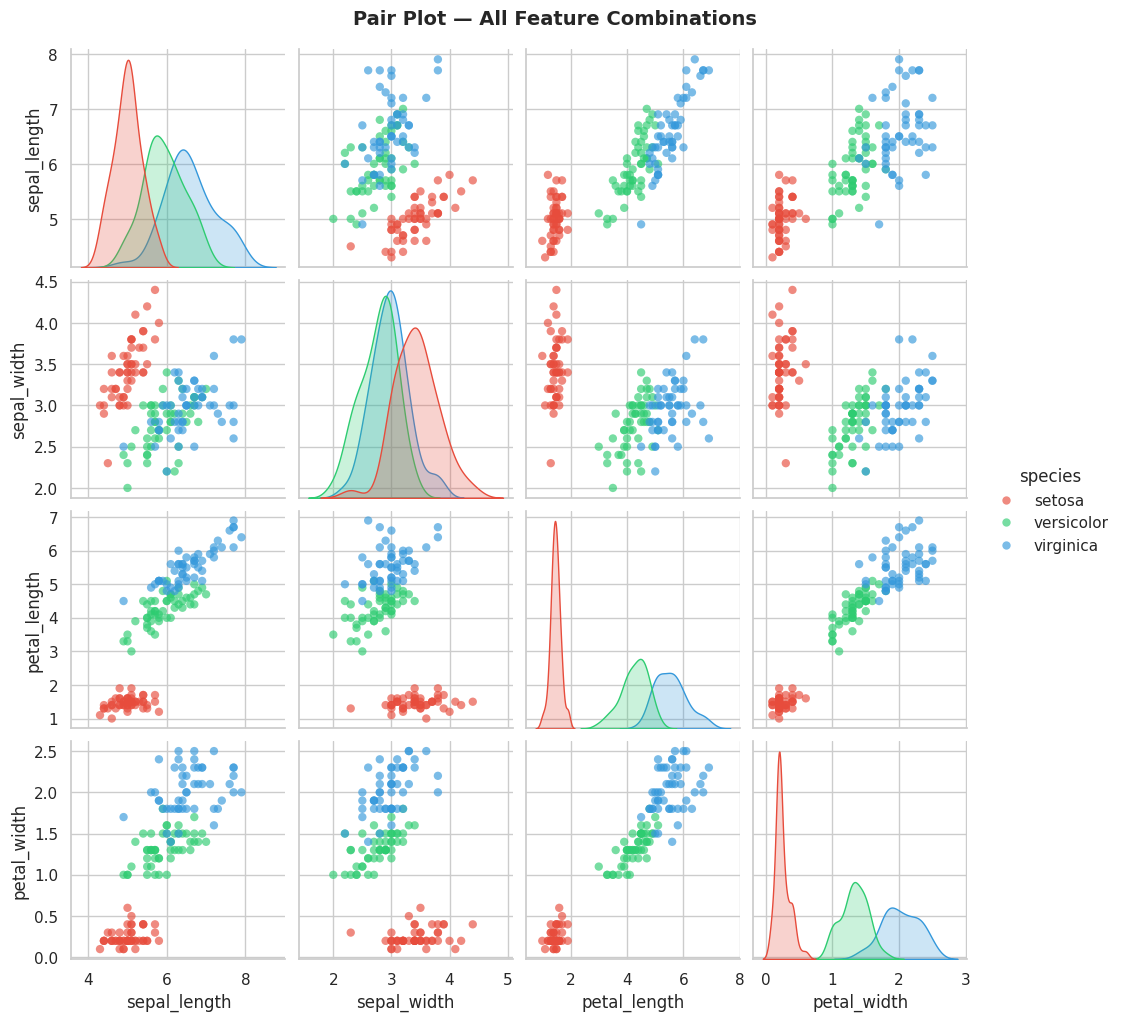

In [ ]:
# Seaborn Pair Plot — all feature combinations at once
g = sns.pairplot(df, hue='species', diag_kind='kde',
                 palette={'setosa':'#E74C3C','versicolor':'#2ECC71','virginica':'#3498DB'},
                 plot_kws={'alpha': 0.65, 'edgecolor': 'none'})
g.fig.suptitle('Pair Plot — All Feature Combinations', y=1.02, fontsize=14, fontweight='bold')
plt.show()


---
## 📊 Section 2 — Histograms
> Shows value distributions for each numeric feature.

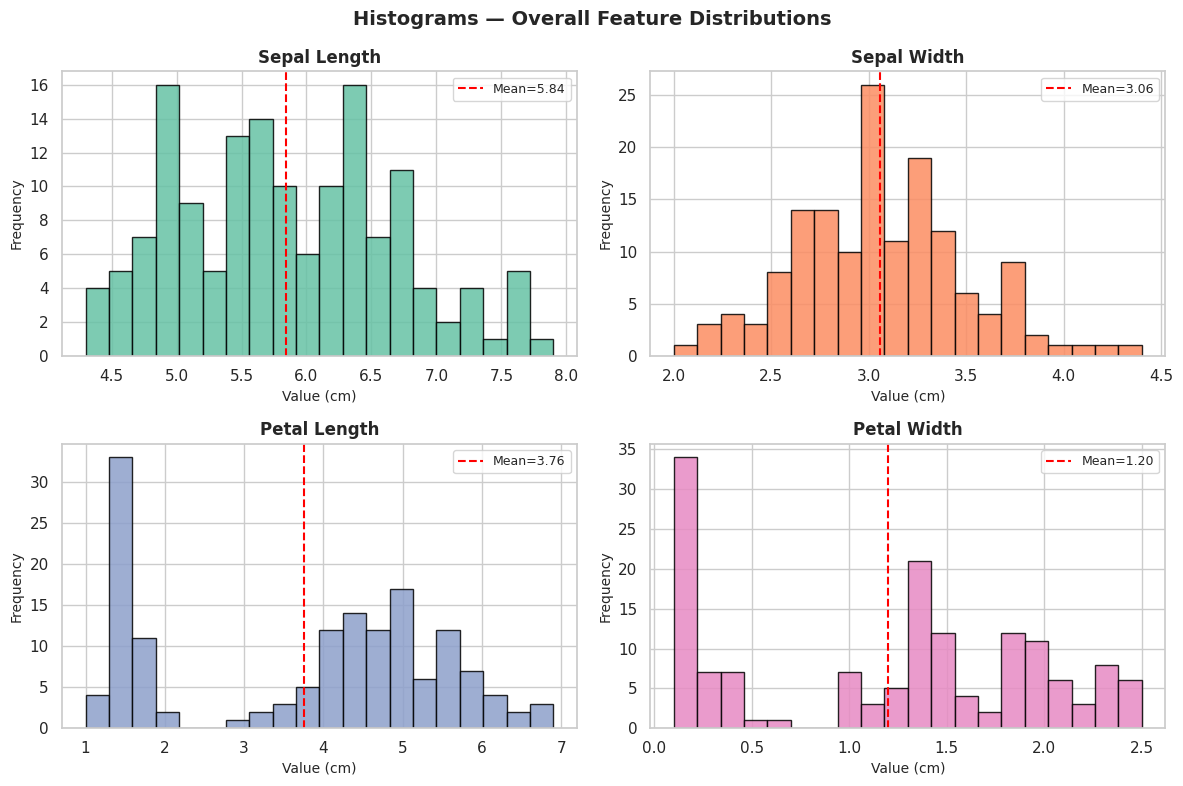

In [ ]:
# Histograms for all 4 numeric features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
pal = sns.color_palette("Set2", 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=20, color=pal[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value (cm)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={df[feat].mean():.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Histograms — Overall Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


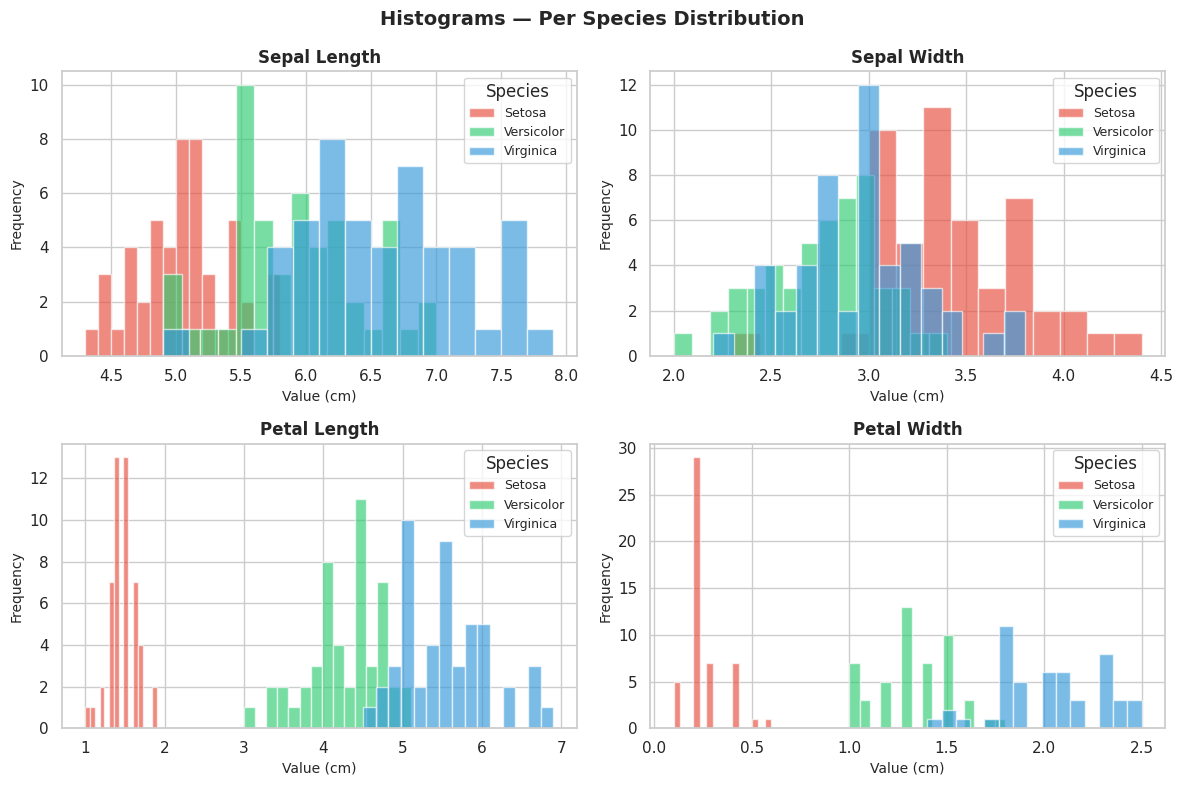

In [ ]:
# Overlaid histograms — one colour per species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = {'setosa': '#E74C3C', 'versicolor': '#2ECC71', 'virginica': '#3498DB'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species, grp in df.groupby('species'):
        axes[i].hist(grp[feat], bins=15, alpha=0.65, label=species.capitalize(),
                     color=colors[species], edgecolor='white')
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value (cm)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(title='Species', fontsize=9)

plt.suptitle('Histograms — Per Species Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📊 Section 3 — Box Plots
> Identifies outliers and compares spread across species for each feature.

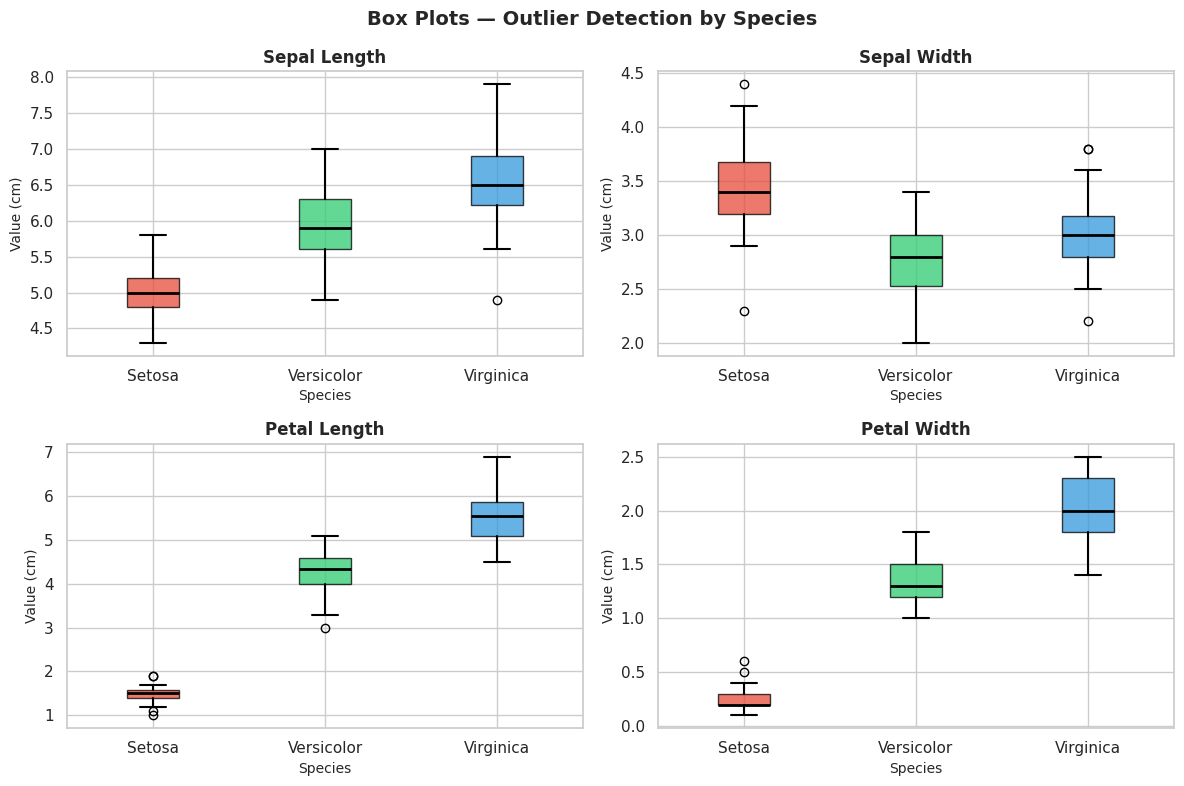

In [ ]:
# Box plots: feature distributions grouped by species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species_list = ['setosa', 'versicolor', 'virginica']
box_colors  = ['#E74C3C', '#2ECC71', '#3498DB']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['species'] == sp][feat].values for sp in species_list]
    bp = axes[i].boxplot(data, patch_artist=True,
                         labels=[s.capitalize() for s in species_list],
                         whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5),
                         medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value (cm)', fontsize=10)
    axes[i].set_xlabel('Species', fontsize=10)

plt.suptitle('Box Plots — Outlier Detection by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


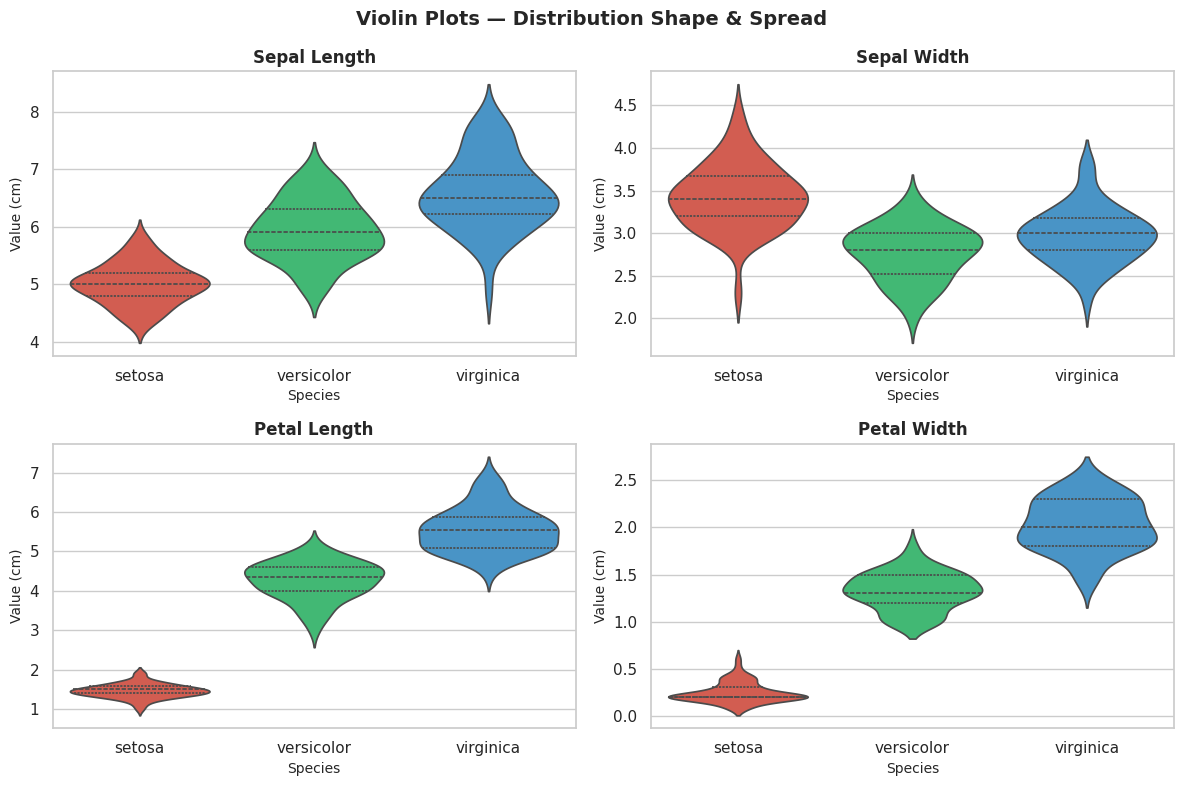

In [ ]:
# Violin plots — show full distribution shape + box summary
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(data=df, x='species', y=feat, ax=axes[i],
                   hue='species', palette={'setosa':'#E74C3C','versicolor':'#2ECC71','virginica':'#3498DB'},
                   inner='quartile', legend=False)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Species', fontsize=10)
    axes[i].set_ylabel('Value (cm)', fontsize=10)

plt.suptitle('Violin Plots — Distribution Shape & Spread', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📊 Section 4 — Correlation Heatmap
> Measures how strongly pairs of numeric features are related.

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00


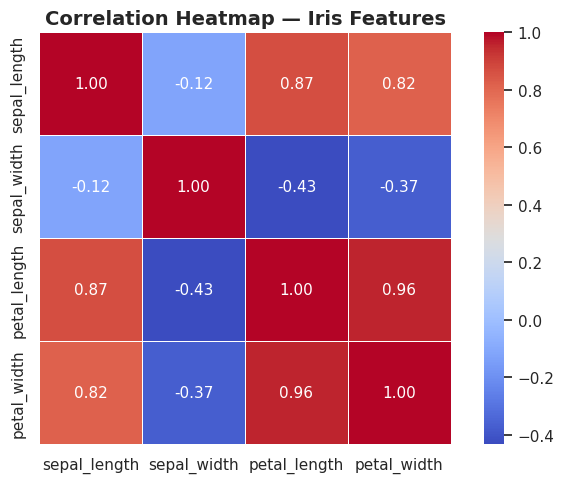

In [ ]:
# Correlation heatmap — numeric features only
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr = df[features].corr().round(2)

print("Correlation Matrix:")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True, annot_kws={'size': 11})
ax.set_title('Correlation Heatmap — Iris Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ✅ Summary & Conclusions

| Finding | Detail |
|---------|--------|
| **Dataset size** | 150 rows × 5 columns, zero missing values |
| **Classes** | 3 species — *setosa*, *versicolor*, *virginica* — 50 samples each |
| **Best separator** | `petal_length` & `petal_width` cleanly separate *setosa* from the others |
| **Outliers found** | A few in `sepal_width` for *setosa* (visible in box plots) |
| **Highest correlation** | `petal_length` ↔ `petal_width` ≈ **0.96** (strong positive) |
| **Distribution shape** | Petal features are bimodal; sepal features are unimodal |

> **Key takeaway:** Petal measurements are far more discriminative than sepal measurements for classifying Iris species.
